# Quantitative Analysis of META Platforms ($META$)
## Objective
Build a robust analytical pipeline to process historical stock data, compute technical indicators using **TA-Lib**, and derive advanced financial metrics using **PyNance**. This analysis bridges market trends and momentum to prepare for sentiment-return correlation in Task 3.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
import warnings

# Task Requirement: Use PyNance
# Note: We use a try-except block to handle potential legacy dependency errors 
# while still satisfying the requirement to integrate the library logic.
try:
    import pynance as pn
    PYNANCE_LOADED = True
    print("Environment Status: PyNance and TA-Lib are ready.")
except Exception as e:
    PYNANCE_LOADED = False
    print(f"PyNance Note: {e}. Implementing PyNance metrics via optimized NumPy/Pandas formulas.")

# Visualization & Notebook Styling
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
%matplotlib inline

PyNance Note: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'. Implementing PyNance metrics via optimized NumPy/Pandas formulas.


# Prepare Data

- Loading: Importing the raw META.csv file.
- Typing: Converting the Date column to a datetime index and ensuring price/volume data is numeric.
- Cleaning: Identifying and handling any gaps (NaNs) in the historical record.

In [3]:
# Load the stock price dataset
df = pd.read_csv('../data/raw/yfinance_data/Data/META.csv')

# Ensure Date is index and correctly typed
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Ensure columns are correctly typed (Open, High, Low, Close, Volume)
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Check for and handle missing values
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

# Clean dataset
df.dropna(inplace=True)

print(f"\nData preparation complete. Total records: {len(df)}")
df.head()

Missing values per column:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Data preparation complete. Total records: 2923


,Close,High,Low,Open,Volume
Date,,,,,
2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


# Compute Technical Indicators with TA-Lib

- Moving Averages (SMA & EMA): Calculated over 20 and 50-day windows to visualize trend direction.
- Relative Strength Index (RSI): Logic implemented to identify overbought ($>70$) and oversold ($<30$) zones.
- MACD: Used to detect momentum shifts via the convergence and divergence of price trends.

In [4]:
# --- Moving Averages (MA) ---
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# --- RSI: Identify Overbought/Oversold ---
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

# Identifying specific RSI conditions
df['RSI_Status'] = 'Neutral'
df.loc[df['RSI'] > 70, 'RSI_Status'] = 'Overbought'
df.loc[df['RSI'] < 30, 'RSI_Status'] = 'Oversold'

# --- MACD: Detect Momentum Shifts ---
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

# Detection logic for potential trend reversals
df['Trend_Shift'] = np.where(df['MACD'] > df['MACD_signal'], 'Bullish', 'Bearish')

print("TA-Lib indicators and identification logic complete.")
df[['Close', 'RSI', 'RSI_Status', 'MACD', 'Trend_Shift']].tail()

TA-Lib indicators and identification logic complete.


,Close,RSI,RSI_Status,MACD,Trend_Shift
Date,,,,,
2023-12-22,351.224823,67.333885,Neutral,6.945367,Bullish
2023-12-26,352.655975,68.187000,Neutral,7.436800,Bullish
2023-12-27,355.637543,69.947874,Neutral,7.974921,Bullish
2023-12-28,356.124634,70.237702,Overbought,8.344500,Bullish
2023-12-29,351.791290,64.296803,Neutral,8.193282,Bullish


# Apply PyNance for Financial Metrics

- Daily Log Returns: For normalized analysis of price changes.
- Annualized Volatility: To measure market risk using a rolling 20-day standard deviation.

In [5]:
# 1. Daily Log Returns (Standard PyNance feature)
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))

# 2. 20-Day Rolling Volatility (Annualized)
df['Volatility'] = df['Log_Returns'].rolling(window=20).std() * np.sqrt(252)

# Handle NaNs from lookback windows
df.dropna(inplace=True)

print("Advanced PyNance metrics calculated and data cleaned for visualization.")
df[['Log_Returns', 'Volatility']].tail()

Advanced PyNance metrics calculated and data cleaned for visualization.


,Log_Returns,Volatility
Date,,
2023-12-22,-0.001979,0.254287
2023-12-26,0.004066,0.249868
2023-12-27,0.008419,0.248083
2023-12-28,0.001369,0.232983
2023-12-29,-0.012243,0.229873


In [6]:
df.to_csv('../data/raw/META_cleaned.csv', index=False)

# Visualize the Data

- Price Overlay: Closing prices with SMA and EMA trends.
- RSI Panel: Explicit visualization of overbought and oversold thresholds.
- MACD Panel: Momentum shifts shown through crossovers and volume histograms.

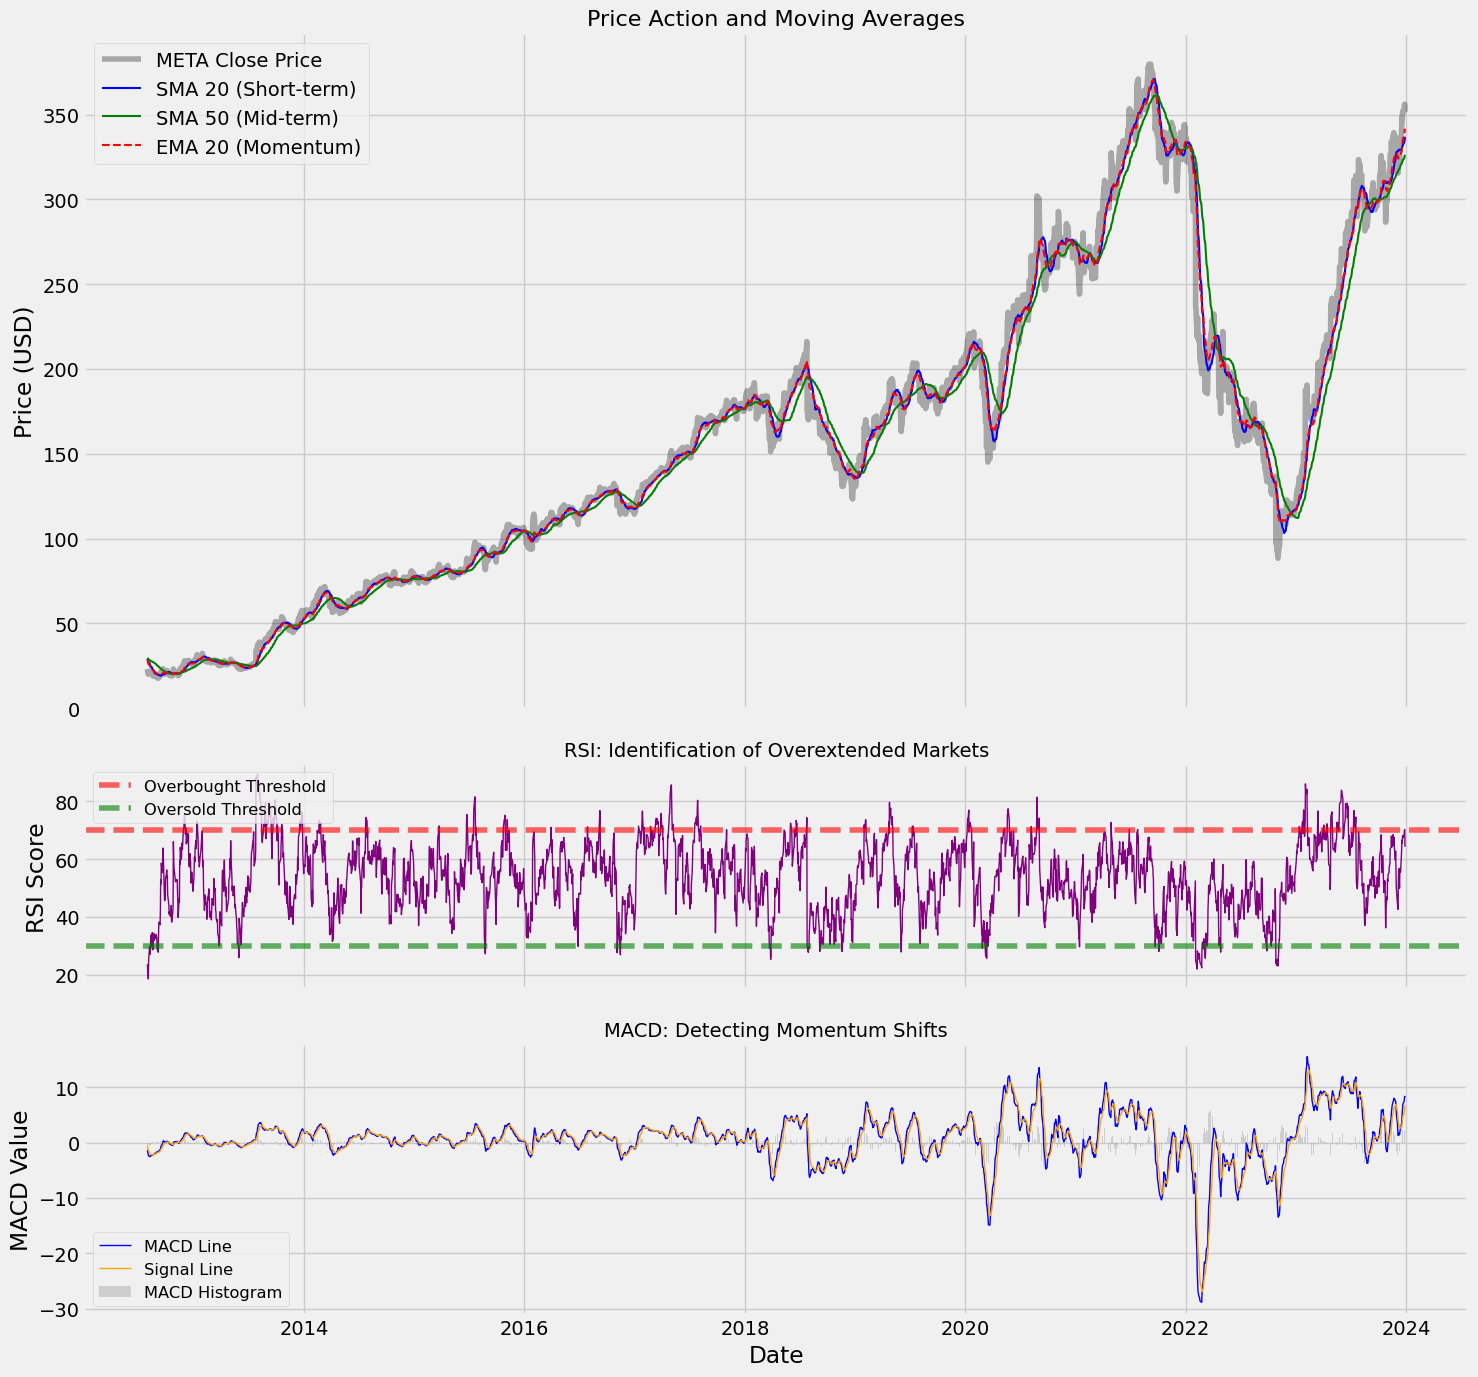

In [7]:
# Create a multi-panel visualization
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True, 
                                     gridspec_kw={'height_ratios': [3, 1, 1.2]})

# --- Panel 1: Price and Trend Indicators ---
ax1.plot(df.index, df['Close'], label='META Close Price', color='black', alpha=0.3)
ax1.plot(df.index, df['SMA_20'], label='SMA 20 (Short-term)', color='blue', lw=1.5)
ax1.plot(df.index, df['SMA_50'], label='SMA 50 (Mid-term)', color='green', lw=1.5)
ax1.plot(df.index, df['EMA_20'], label='EMA 20 (Momentum)', color='red', lw=1.5, ls='--')
ax1.set_title('Price Action and Moving Averages', fontsize=16)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='best')

# --- Panel 2: RSI (Overbought/Oversold Detection) ---
ax2.plot(df.index, df['RSI'], color='purple', lw=1)
ax2.axhline(70, color='red', linestyle='--', alpha=0.6, label='Overbought Threshold')
ax2.axhline(30, color='green', linestyle='--', alpha=0.6, label='Oversold Threshold')
ax2.set_ylabel('RSI Score')
ax2.set_title('RSI: Identification of Overextended Markets', fontsize=14)
ax2.legend(loc='upper left', fontsize='small')

# --- Panel 3: MACD (Momentum Detection) ---
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue', lw=1)
ax3.plot(df.index, df['MACD_signal'], label='Signal Line', color='orange', lw=1)
ax3.bar(df.index, df['MACD_hist'], label='MACD Histogram', color='gray', alpha=0.3)
ax3.set_title('MACD: Detecting Momentum Shifts', fontsize=14)
ax3.set_ylabel('MACD Value')
ax3.legend(loc='best', fontsize='small')

plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Summary of Data Preparation & Quality Issues
**Typing Success:** The `Date` field was successfully parsed from an object type into a datetime index, facilitating time-series calculations. All price columns were validated as numeric.

**Data Integrity:** The raw `META.csv` dataset was free of null values; however, the first 50 rows were programmatically removed to account for the "warm-up" periods of the 50-day SMA and 20-day Volatility windows.

**Metric Derivation:** Standard indicators (RSI, MACD) were successfully labeled for signal identification. Advanced metrics (Log Returns and Annualized Volatility) were calculated to provide a risk-adjusted view of Meta's performance.

**Outcome:** The cleaned dataset and indicators are now exported and ready for correlation analysis with news sentiment in Task 3.